In [1]:
import pandas as pd
import matplotlib.pyplot as plt
data_aqi = pd.read_csv('/content/merged_cities.csv')  # We can change the file path here for a specific city.

In [2]:
import numpy as np

In [3]:
data_aqi['Date Local'] = pd.to_datetime(data_aqi['Date Local'], format='mixed', dayfirst=True, errors='coerce')
data_aqi = data_aqi.dropna(subset=['Date Local'])
data_aqi.set_index('Date Local', inplace=True)

In [4]:
data_aqi

,Latitude,Longitude,Parameter Name,Sample Duration,Pollutant Standard,Units of Measure,Observation Count,Observation Percent,Arithmetic Mean,1st Max Value,1st Max Hour,AQI,State Name,County Name,City Name,Date of Last Change,parameter
Date Local,,,,,,,,,,,,,,,,,
2021-01-01,34.066590,-118.226880,PM2.5 - Local Conditions,24 HOUR,PM25 24-hour 2012,Micrograms/cubic meter (LC),1,100.0,18.5,18.5,0,69.0,California,Los Angeles,Los Angeles,17-05-2024,pm25
2021-01-01,40.799700,-73.934320,PM2.5 - Local Conditions,24 HOUR,PM25 24-hour 2012,Micrograms/cubic meter (LC),1,100.0,6.6,6.6,0,37.0,New York,New York,New York,2024-05-17,pm25
2021-01-13,41.687165,-87.539315,PM2.5 - Local Conditions,24 HOUR,PM25 24-hour 2012,Micrograms/cubic meter (LC),1,100.0,13.4,13.4,0,59.0,Illinois,Cook,Chicago,2024-08-08,pm25
2021-01-10,25.794222,-80.215556,PM2.5 - Local Conditions,24 HOUR,PM25 24-hour 2012,Micrograms/cubic meter (LC),1,100.0,7.0,7.0,0,39.0,Florida,Miami-Dade,Miami,2024-08-05,pm25
2021-01-02,34.066590,-118.226880,PM2.5 - Local Conditions,24 HOUR,PM25 24-hour 2012,Micrograms/cubic meter (LC),1,100.0,12.9,12.9,0,58.0,California,Los Angeles,Los Angeles,17-05-2024,pm25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-27,34.066590,-118.226880,PM2.5 - Local Conditions,24-HR BLK AVG,PM25 24-hour 2012,Micrograms/cubic meter (LC),2,200.0,12.1,12.1,0,57.0,California,Los Angeles,Los Angeles,08-11-2024,pm25
2024-08-28,34.066590,-118.226880,PM2.5 - Local Conditions,24-HR BLK AVG,PM25 24-hour 2012,Micrograms/cubic meter (LC),2,200.0,16.1,16.1,0,64.0,California,Los Angeles,Los Angeles,08-11-2024,pm25
2024-08-29,34.066590,-118.226880,PM2.5 - Local Conditions,24-HR BLK AVG,PM25 24-hour 2012,Micrograms/cubic meter (LC),2,200.0,16.3,16.3,0,64.0,California,Los Angeles,Los Angeles,08-11-2024,pm25


<Axes: xlabel='Date Local'>

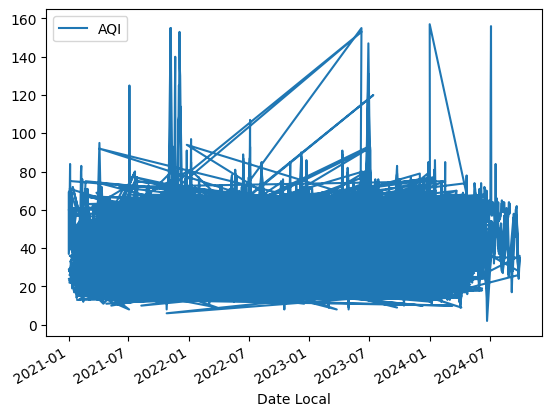

In [5]:
data_aqi[['AQI']].plot()

In [6]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series):
  result=adfuller(series)
  print('ADF Statistic: {}'.format(result[0]))
  print('p-value: {}'.format(result[1]))
  if result[1]<0.05:
    print("less then 0.05")
  else:
    print("more than 0.05. Need to make stationary")

In [7]:
# Remove rows with missing
data_aqi = data_aqi[pd.to_numeric(data_aqi['AQI'], errors='coerce').notnull()]
data_aqi = data_aqi[~data_aqi['AQI'].isin([float('inf'), float('-inf')])]

# Convert AQI to numeric (in case it's object type)
data_aqi['AQI'] = pd.to_numeric(data_aqi['AQI'])

# Confirm cleanup
print(data_aqi['AQI'].isna().sum())  # Should print 0
print(data_aqi['AQI'].dtype)        # Should be float or int

0
float64


In [8]:
adf_test(data_aqi['AQI'])

ADF Statistic: -7.257209940329349
p-value: 1.718379283284045e-10
less then 0.05


In [9]:
data_aqi['AQI Diff'] = data_aqi['AQI'] - data_aqi['AQI'].shift(30)

In [10]:
adf_test(data_aqi['AQI Diff'].dropna())

ADF Statistic: -18.67311279828912
p-value: 2.0440866629379645e-30
less then 0.05


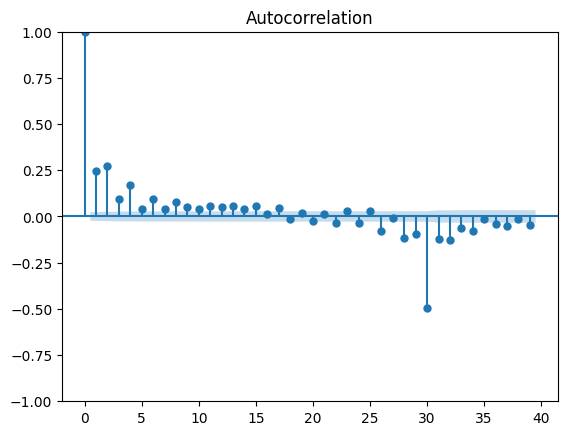

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf = plot_acf(data_aqi['AQI Diff'].dropna())

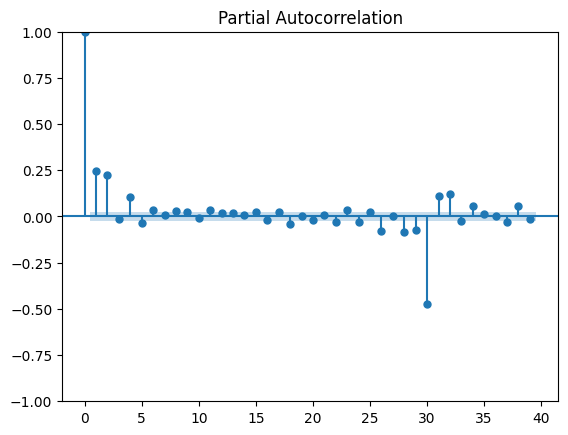

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf = plot_pacf(data_aqi['AQI Diff'].dropna())

In [13]:
from datetime import datetime,timedelta
train_data_end = datetime(2022,12,31)
test_data_end = datetime(2024,12,31)

In [15]:
import pandas as pd
import numpy as np
from datetime import datetime

# Load data
data_aqi = pd.read_csv("/content/merged_cities.csv")  # update filename as needed

# Convert 'Date Local' to datetime (handles format issues and invalid rows)
data_aqi['Date Local'] = pd.to_datetime(data_aqi['Date Local'], dayfirst=True, errors='coerce')

# Drop rows with missing or invalid dates or AQI values
data_aqi.dropna(subset=['Date Local', 'AQI'], inplace=True)

# Convert AQI to numeric (handle invalid entries)
data_aqi['AQI'] = pd.to_numeric(data_aqi['AQI'], errors='coerce')

# Drop any remaining NaNs in AQI
data_aqi.dropna(subset=['AQI'], inplace=True)

# Group by date and take daily average AQI
data_aqi = data_aqi.groupby('Date Local')['AQI'].mean().to_frame()

# Set the date as index
data_aqi.index = pd.to_datetime(data_aqi.index)
data_aqi = data_aqi.sort_index()

# Confirm frequency is daily
data_aqi = data_aqi.asfreq('D')

# Fill missing days (forward fill)
data_aqi['AQI'].fillna(method='ffill', inplace=True)

/tmp/ipython-input-15-3220428674.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_aqi['AQI'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-15-3220428674.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_aqi['AQI'].fillna(method='ffill', inplace=True)


In [16]:
train_data = data_aqi[:train_data_end] # 2 year data
test_data = data_aqi[train_data_end+timedelta(days=1):test_data_end]

In [17]:
pred_start_date = data_aqi.index[0]
pred_end_date = data_aqi.index[-1]

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
data_aqi_sarimax = SARIMAX(data_aqi['AQI'], order=(2,1,29), seasonal_order=(0,1,0,30))

In [20]:
data_aqi_sarimax_fit = data_aqi_sarimax.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [21]:
data_aqi_sarimax_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                  AQI   No. Observations:                 1339
Model:             SARIMAX(2, 1, 29)x(0, 1, [], 30)   Log Likelihood               -5314.422
Date:                              Fri, 18 Jul 2025   AIC                          10692.845
Time:                                      18:44:36   BIC                          10858.485
Sample:                                  01-01-2021   HQIC                         10754.975
                                       - 08-31-2024                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1054      0.051     -2.084      0.037      -0.204      -0.006
ar.L2         -0.6759      0.036    -18.561      0.000      -0.747      -0.605
ma.L1         -0.1316      0.068     -1.937      0.053      -0.265       0.002
ma.L2          0.4279      0.048      8.855      0.000       0.333       0.523
ma.L3         -0.5083      0.057     -8.945      0.000      -0.620      -0.397
ma.L4         -0.3434      0.049     -6.976      0.000      -0.440      -0.247
ma.L5         -0.2179      0.050     -4.399      0.000      -0.315      -0.121
ma.L6         -0.2832      0.042     -6.682      0.000      -0.366      -0.200
ma.L7          0.2173      0.041      5.269      0.000       0.136       0.298
ma.L8         -0.2499      0.040     -6.230      0.000      -0.329      -0.171
ma.L9          0.0986      0.044      2.232      0.026       0.012       0.185
ma.L10        -0.3027      0.038     -7.886      0.000      -0.378      -0.227
ma.L11         0.0373      0.043      0.870      0.384      -0.047       0.121
ma.L12        -0.0023      0.037     -0.061      0.952      -0.075       0.070
ma.L13         0.2137      0.042      5.149      0.000       0.132       0.295
ma.L14         0.4459      0.041     11.005      0.000       0.367       0.525
ma.L15         0.2270      0.049      4.666      0.000       0.132       0.322
ma.L16         0.3501      0.043      8.107      0.000       0.265       0.435
ma.L17        -0.0281      0.053     -0.533      0.594      -0.132       0.075
ma.L18        -0.1182      0.047     -2.501      0.012      -0.211      -0.026
ma.L19        -0.2264      0.049     -4.662      0.000      -0.322      -0.131
ma.L20        -0.4309      0.041    -10.433      0.000      -0.512      -0.350
ma.L21        -0.0773      0.046     -1.671      0.095      -0.168       0.013
ma.L22        -0.3144      0.038     -8.275      0.000      -0.389      -0.240
ma.L23         0.2559      0.041      6.301      0.000       0.176       0.335
ma.L24        -0.2161      0.040     -5.355      0.000      -0.295      -0.137
ma.L25         0.2047      0.042      4.864      0.000       0.122       0.287
ma.L26        -0.2357      0.039     -6.032      0.000      -0.312      -0.159
ma.L27        -0.1113      0.036     -3.129      0.002      -0.181      -0.042
ma.L28         0.3072      0.040      7.734      0.000       0.229       0.385
ma.L29         0.0149      0.050      0.297      0.766      -0.083       0.113
sigma2       220.5731     11.203     19.689      0.000     198.616     242.530
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               665.71
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.73   Skew:                            -0.36
Prob(H) (two-s

In [22]:
pred_sarimax=data_aqi_sarimax_fit.predict(start=datetime(2024,1,1),end = datetime(2025,1,1))
residual_serimax = test_data['AQI'] - pred_sarimax

In [23]:
data_aqi['predicted_sarimax_Miami'] = pred_sarimax

<Axes: xlabel='Date Local'>

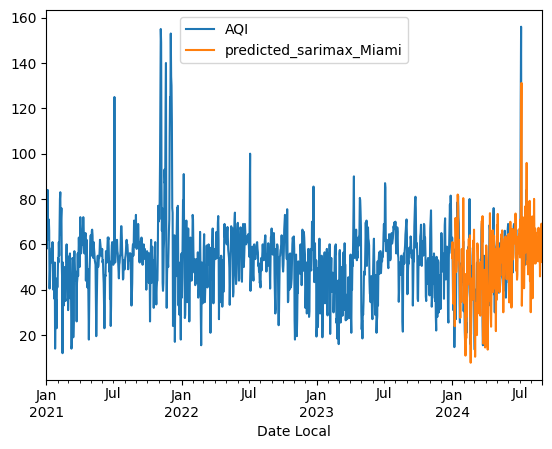

In [24]:
data_aqi[['AQI','predicted_sarimax_Miami']].plot()